# Assignment 2 · the video pipeline, modelled

*Every step of the video specification as a few lines of numpy on a synthetic piano picture, so that you can see
what each block does before you build it, and predict what the second picture and the tutor's photograph will
do to your detector.*

The pictures are 320 × 240 8-bit grey, exactly what the board stores. Every function is the float twin of a
hardware block: `grad1d` is the workspace's `hdiff.sv`, `profile` is `col_profile.sv`, `pick_runs` is `pick_runs.sv`,
`conv3` is `conv3x3.sv` and `pick_spaced` / `pick_nms_hyst` are the peak pickers you write from R-V3 up.

| Rung | Stage | Section |
|---|---|---|
| R-V0 Pass A | the edge map: the workspace's 1-D difference, or the Sobel table | 1, 1a |
| R-V1 Pass B | the column profile and a fixed-threshold picker, so the keys are found | 2, 3 |
| R-V2 Credit | the 3 × 3 Sobel table on line buffers: the noisy second picture reads | 1, 1a, 4 |
| R-V3 Distinction | divide by the maximum, local maxima only, minimum spacing, two thresholds | 4, 4a |
| R-V4 High Distinction | a smoothing table before the Sobel, a threshold that follows the local level: the photograph | 5 |
| Extras | a keyboard is a pattern: the lattice fit that rejects the shadow's edge | 6 |

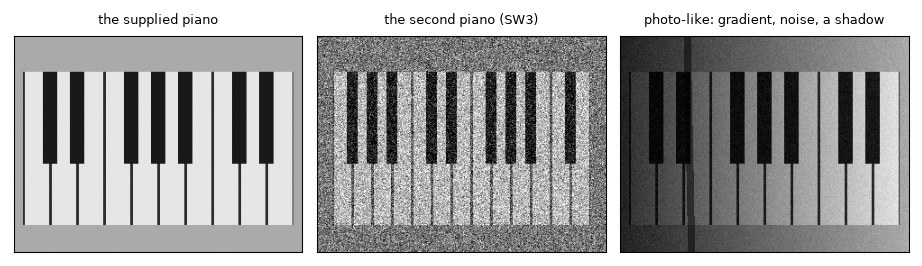

true key boundaries of picture 1: [10, 40, 70, 100, 130, 160, 190, 220, 250, 280, 310]


In [1]:
import numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 140, "font.size": 7, "axes.titlesize": 6.5, "lines.linewidth": 1.1, "axes.linewidth": 0.55, "xtick.major.width": 0.55, "ytick.major.width": 0.55})   # Ed shows 950 px
from video_model import *
(img1, edges1, blacks1), (img2, edges2, blacks2), (img3, _, _) = demo_images()
fig, ax = plt.subplots(1, 3, figsize=(6.6, 1.87))
for a, im, t in zip(ax, (img1, img2, img3), ("the supplied piano", "the second piano (SW3)", "photo-like: gradient, noise, a shadow")):
    a.imshow(im, cmap="gray", vmin=0, vmax=255); a.set_title(t); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("true key boundaries of picture 1:", edges1)

## 1. Sobel a derivative across the picture

The 3 × 3 table `[-1 0 1; -2 0 2; -1 0 1]` slid over the picture gives Gx, how much brighter the right side is
than the left. Flat areas give 0; the dark gap between two white keys gives a negative spike on its left side and a
positive one on its right. Its transpose gives Gy (horizontal edges: the bottom of the black keys, the ends of the
white keys).

In hardware the nine pixels come from two **line buffers** (the two previous rows in RAM) and a 3-deep shift of
column triples. The output is one row and one column late, and only for interior pixels.

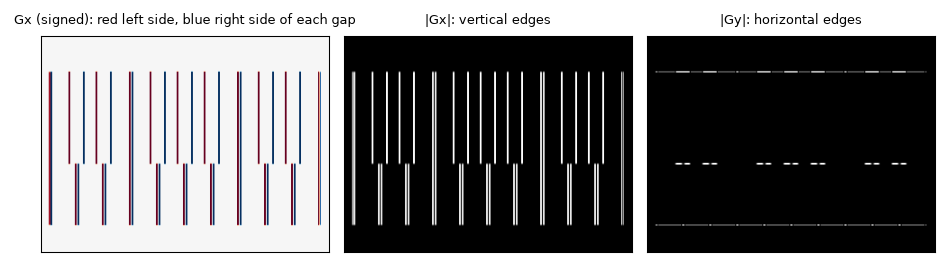

In [2]:
gx, gy, mag = sobel_mag(img1)
fig, ax = plt.subplots(1, 3, figsize=(6.6, 1.87))
ax[0].imshow(conv3(img1, SOBEL_X), cmap="RdBu", vmin=-600, vmax=600); ax[0].set_title("Gx (signed): red left side, blue right side of each gap")
ax[1].imshow(gx, cmap="gray"); ax[1].set_title("|Gx|: vertical edges")
ax[2].imshow(gy, cmap="gray"); ax[2].set_title("|Gy|: horizontal edges")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### 1a. The workspace's 1-D difference (R-V0), and why the Sobel table replaces it (R-V2)

The Mini-Project 2 workspace ships the simplest edge detector: `|p[x] − p[x−1]|` along each row, no line
buffers. On the supplied piano it is all you need. The Sobel table is the same difference plus an average over
three rows, and that average is what survives the second picture's grain: a noisy pixel is one spike to the
1-D difference and a third of one to Sobel. Same profile, same run picker, both pictures:

1-D difference, picture 1                  found 11  true 11  matched 11  spurious  0
Sobel |Gx|, picture 1                      found 11  true 11  matched 11  spurious  0
1-D difference, picture 2, noisy           found 20  true 14  matched 11  spurious  9
Sobel |Gx|, picture 2, noisy               found 14  true 14  matched 14  spurious  0


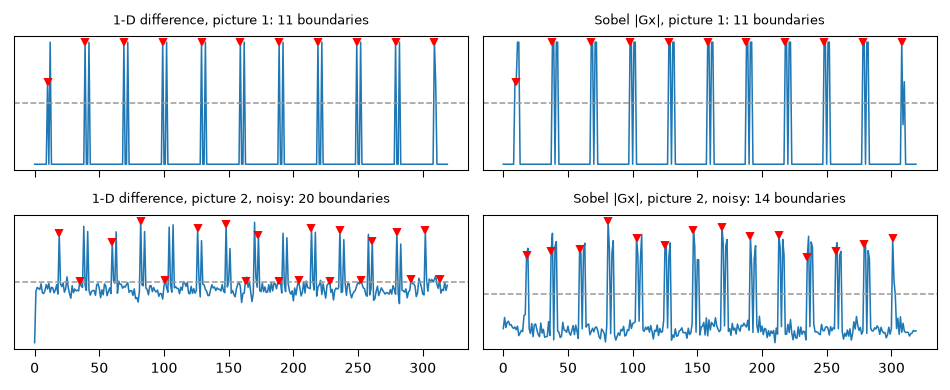

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(6.8, 2.8), sharex=True)
for row, (im, edges, name) in enumerate(((img1, edges1, "picture 1"), (img2, edges2, "picture 2, noisy"))):
    p1d = profile(grad1d(im), Y0, Y1); psb = profile(sobel_mag(im)[0], Y0, Y1)
    for col, (pr, det) in enumerate(((p1d, "1-D difference"), (psb, "Sobel |Gx|"))):
        thr = 0.5 * pr.max(); found = pick_runs(pr, thr, min_gap=8)
        report(f"{det}, {name}", found, edges)
        ax[row, col].plot(pr, lw=0.8); ax[row, col].axhline(thr, color="#999", ls="--", lw=0.8); ax[row, col].plot(found, pr[found], "rv", ms=3)
        ax[row, col].set_title(f"{det}, {name}: {len(found)} boundaries"); ax[row, col].set_yticks([])
plt.tight_layout(); plt.show()

## 2. The column profile: a picture into a signal

Sum |Gx| down each column, but **only over rows below the black keys**: above them every black key adds two
more edges and hides the gaps. Which rows is your first stated design decision (`Y0`, `Y1` in `col_profile.sv`).
Try summing all rows and count the spikes.

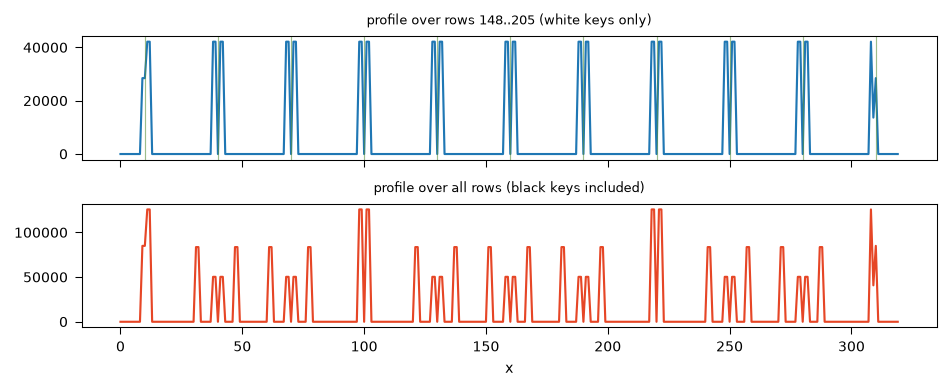

In [4]:
prof_white = profile(gx, Y0, Y1)
prof_all = profile(gx, 0, H)
fig, ax = plt.subplots(2, 1, figsize=(6.8, 2.8), sharex=True)
ax[0].plot(prof_white); ax[0].set_title(f"profile over rows {Y0}..{Y1} (white keys only)")
ax[1].plot(prof_all, color="#E64626"); ax[1].set_title("profile over all rows (black keys included)"); ax[1].set_xlabel("x")
for e in edges1: ax[0].axvline(e, color="#5C923E", lw=0.6, alpha=0.6)
plt.tight_layout(); plt.show()

## 3. A fixed threshold picker

Every column above a fixed number is a boundary. On the supplied picture this works, if you pick the number by
looking at the profile (that is what the profile view on SW2 is for). Two things to notice: each gap gives **two**
spikes (its two sides), and the threshold is in absolute units, so it is only right for this picture.

fixed threshold, picture 1                 found 20  true 11  matched 11  spurious  0


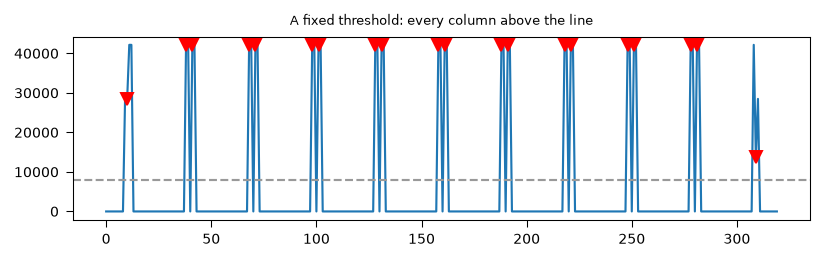

In [5]:
prof, prof_n, found, _ = run(img1, thr_fixed=8000)
report("fixed threshold, picture 1", found, edges1)
plt.figure(figsize=(6.8, 1.7)); plt.plot(prof); plt.axhline(8000, color="#999", ls="--"); plt.plot(found, prof[found], "rv"); plt.title("A fixed threshold: every column above the line"); plt.show()

## 4. Normalise, local maxima, minimum spacing

Three fixes, each for a specific failure of the fixed threshold:

1. **divide by the maximum**: the threshold becomes a fraction (0.35), the same for any picture and lighting;
2. **local maxima only**: a spike is one column, not a run of columns;
3. **minimum spacing** (`min_gap`): two spikes closer than a third of a key are the two sides of one gap: keep
   the larger. That is what turns 20 candidates into 11 boundaries.

Same parameters, second picture: still right. Then the photo-like picture: the shadowed half drops below the
fraction and two boundaries go missing. That failure is the probe for the next step.

fraction + maxima, picture 1               found 11  true 11  matched 11  spurious  0
fraction + maxima, picture 2 (same parameters) found 14  true 14  matched 14  spurious  0
fraction + maxima, photo-like              found  9  true 11  matched  9  spurious  0


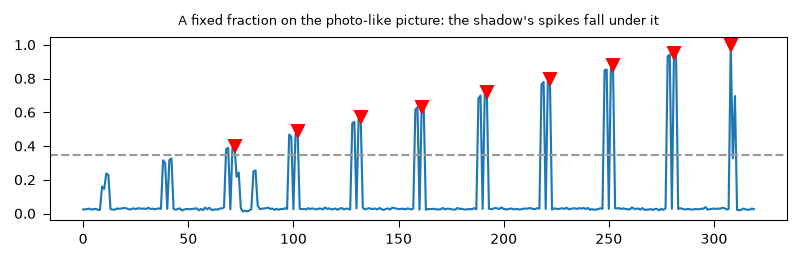

In [6]:
for name, im, truth in (("fraction + maxima, picture 1", img1, edges1), ("fraction + maxima, picture 2 (same parameters)", img2, edges2), ("fraction + maxima, photo-like", img3, edges1)):
    prof, prof_n, found, _ = run(im, min_gap=8, thr_norm=0.35)
    report(name, found, truth)
prof, prof_n, found, _ = run(img3, min_gap=8, thr_norm=0.35)
plt.figure(figsize=(6.8, 1.7)); plt.plot(prof_n); plt.axhline(0.35, color="#999", ls="--"); plt.plot(found, prof_n[found], "rv"); plt.title("A fixed fraction on the photo-like picture: the shadow's spikes fall under it"); plt.show()

### 4a. Two thresholds (hysteresis)

One fraction has to be low enough to catch the faint boundaries and high enough to reject the noise. Two give
you room at both ends: accept a local maximum above the **high** threshold, and keep a weaker one only if it sits
within `min_gap` of an accepted peak (the other side of the same gap), so that a boundary is not split in two and
a lone bump in the noise is not promoted. That is what the specification means by hysteresis at R-V3, and the two
numbers are the ones the demo asks you to move from the board.

On the photo-like picture it fails in two ways at once, and the figure shows both: the shadowed left half drops
below the *low* line, and the peaks in the middle sit *between* the lines with no accepted neighbour to be kept
by. Only the five peaks above the high line survive. No pair of fixed fractions copes with a brightness gradient
(the single fraction of section 4 found nine here, this pair five): that is the next section's job.

two thresholds 0.7 / 0.35, picture 1       found 11  true 11  matched 11  spurious  0
two thresholds 0.7 / 0.35, picture 2, noisy found 14  true 14  matched 14  spurious  0
two thresholds 0.7 / 0.35, photo-like      found  5  true 11  matched  5  spurious  0


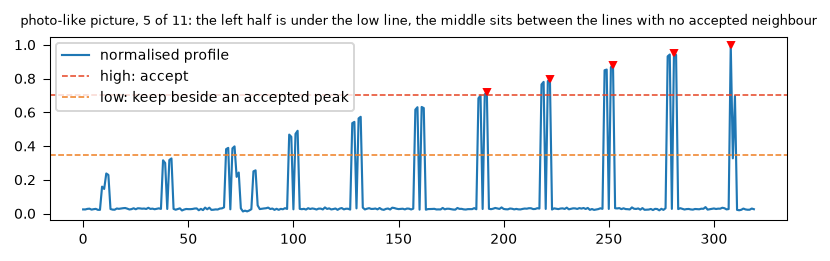

In [7]:
for im, edges, name in ((img1, edges1, "picture 1"), (img2, edges2, "picture 2, noisy"), (img3, edges1, "photo-like")):
    prof, prof_n, _, _ = run(im)
    report(f"two thresholds 0.7 / 0.35, {name}", pick_nms_hyst(prof_n, hi=0.7, lo=0.35, min_gap=10), edges)
prof, prof_n, _, _ = run(img3)
found = pick_nms_hyst(prof_n, hi=0.7, lo=0.35, min_gap=10)
plt.figure(figsize=(6.8, 1.7)); plt.plot(prof_n, label="normalised profile")
plt.axhline(0.7, color="#E64626", ls="--", lw=0.8, label="high: accept"); plt.axhline(0.35, color="#EF8025", ls="--", lw=0.8, label="low: keep beside an accepted peak")
plt.plot(found, prof_n[found], "rv", ms=3); plt.title("photo-like picture, 5 of 11: the left half is under the low line, the middle sits between the lines with no accepted neighbour"); plt.legend(loc="upper left"); plt.show()

## 5. Gaussian filter first, then a threshold that follows the local level

- **Gaussian filter** is the same `conv3x3` module with a different table (`[1 2 1; 2 4 2; 1 2 1] / 16`) *before* the
  Sobel table: noise spikes are averaged away before the derivative amplifies them. Two instances of one module.
- **Adaptive threshold**: `k ×` the local mean of the profile (a moving average over ±12 columns: Lesson 4's FIR
  with all taps equal). In the shadow the local mean is low, so the threshold follows it down. This is the same
  idea as the audio gate's noise floor, and as subtracting the mean from the log-Mel vector: compare to what is
  around you, not to a constant.

smoothed + adaptive, photo-like            found 12  true 11  matched 11  spurious  1


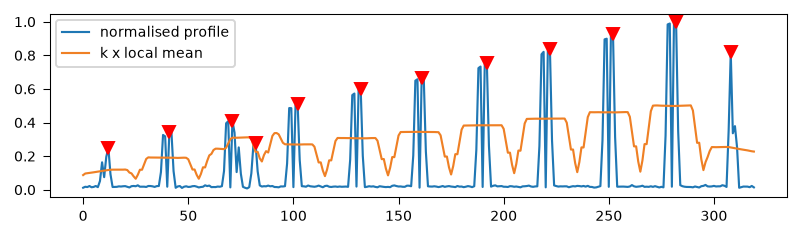

In [8]:
prof, prof_n, found, thr = run(img3, smooth=True, adaptive=True, min_gap=8)
report("smoothed + adaptive, photo-like", found, edges1)
plt.figure(figsize=(6.8, 1.7)); plt.plot(prof_n, label="normalised profile"); plt.plot(thr, color="#EF8025", label="k x local mean"); plt.plot(found, prof_n[found], "rv"); plt.legend(); plt.show()

One spurious boundary survives: the shadow's own edge. No threshold removes it, because it *is* an edge. That is
what the last step is for.

## 6. A keyboard is a pattern

White keys are equally spaced. Take the median spacing of the boundary list and keep only boundaries that sit on
that lattice; the shadow's edge is off-lattice and goes. (The full version also uses a *row* profile of |Gy| to find
the key ends and the black keys, so the lit region is the exact key shape.)

In [9]:
kept, spacing = template_fit(found)
report("Lattice fit", kept, edges1)
print(f"key spacing found: {spacing} px (true: {edges1[1] - edges1[0]})")

Lattice fit                                found 11  true 11  matched 11  spurious  0
key spacing found: 30.0 px (true: 30)


## 7. Things to try before you write RTL

1. Make a picture with 8 keys, or with the piano off-centre, and run all four pickers. Which parameters had to change?
2. Load a real photograph of a keyboard (`tools/any_photo_to_mif.py` in the provided material makes the `.mif`;
   `PIL.Image.open(...).convert("L").resize((320, 240))` gets you the array here). Where does the fixed fraction break?
3. The profile's rows: sweep `Y0` and `Y1` and count boundaries. Write the choice and the reason down; the report asks.

## 8. From here to fixed point

- Sobel of 8-bit pixels needs 12 bits signed (±4 × 255 = ±1020). |Gx| summed over 60 rows needs 18; over 200
  rows, 20. `col_profile.sv` has `AW` for this.
- Normalising by the maximum is one divider per frame walked over 320 entries, or a reciprocal and a multiply.
  A frame is 800 000 pixel clocks at 25 MHz; there is time for anything.
- The local mean over ±12 columns is a 25-tap moving average with all taps 1: a running sum with one add and one
  subtract per column, no multiplier.
- The lattice fit needs a median (sort a few numbers) and a compare with tolerance: small.

## 9. The answer, drawn on the photograph

Everything above is numbers in a list. This is the same list drawn back onto the picture it came from: the
boundaries the lattice fit kept in red, the ones it threw away dashed and grey, and the rows the profile was
summed over shaded. The dashed line through the shadow is the one that mattered — it survived the Sobel, the
smoothing and the adaptive threshold, and only the shape of a keyboard could rule it out.

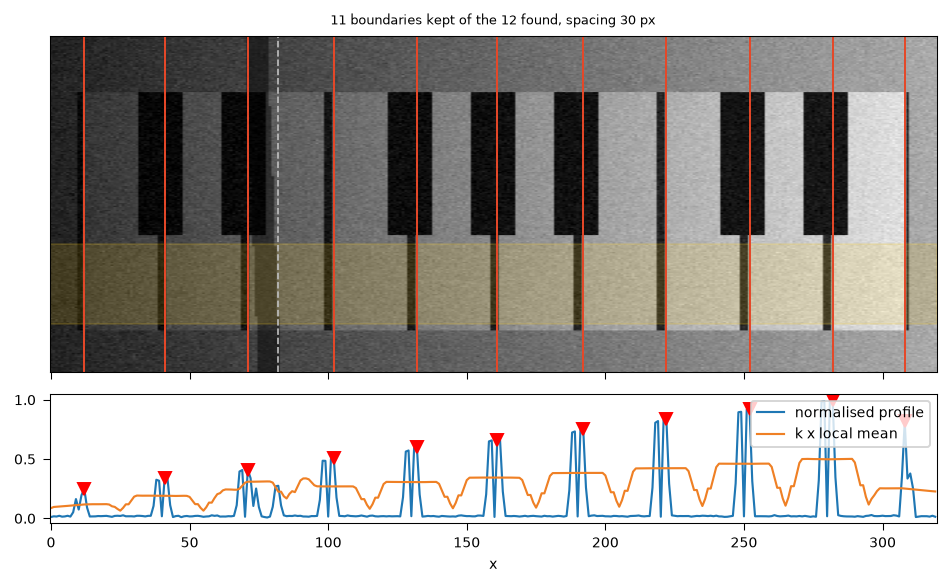

boundaries: [12, 41, 71, 102, 132, 161, 192, 222, 252, 282, 308]   dropped: [82]


In [10]:
prof, prof_n, found, thr = run(img3, smooth=True, adaptive=True, min_gap=8)
kept, spacing = template_fit(found)
fig, ax = plt.subplots(2, 1, figsize=(6.8, 4.2), sharex=True, gridspec_kw={"height_ratios": [2.6, 1]})
ax[0].imshow(img3, cmap="gray", vmin=0, vmax=255, aspect="auto")
ax[0].axhspan(Y0, Y1, color="#FFD020", alpha=0.15)                      # the rows the profile was summed over
for x in found: ax[0].axvline(x, color="#BBBBBB", ls="--", lw=0.9)      # every boundary the picker offered
for x in kept:  ax[0].axvline(x, color="#E64626", lw=1.0)               # the ones on the lattice
ax[0].set_yticks([]); ax[0].set_title(f"{len(kept)} boundaries kept of the {len(found)} found, spacing {spacing:.0f} px")
ax[1].plot(prof_n, label="normalised profile"); ax[1].plot(thr, color="#EF8025", label="k x local mean")
ax[1].plot(kept, prof_n[kept], "rv"); ax[1].set_xlabel("x"); ax[1].legend(loc="upper right")
plt.tight_layout(); plt.show()
print("boundaries:", [int(x) for x in kept], "  dropped:", [int(x) for x in sorted(set(found) - set(kept))])